
# Poverty Traps and Growth Takeoffs in the Neoclassical Model

This notebook implements Value Function Iteration (VFI) for a standard deterministic neoclassical growth economy with log utility and Cobb–Douglas production. It then extends to a balanced-growth version with exogenous TFP growth and performs VFI in stationary (transformed) variables. Finally, it offers a discussion on Poverty Traps.

Planner's problem (stationary case):
$$ v(k) = \max_{c,k'} { \log(c) + \beta v(k') }  \quad s.t.\quad  c + k' \leq A k^\alpha + (1 - \delta) k, k>0.$$


Balanced growth: $$A_{t+1} = (1 + \gamma) A_t$$ 

Defining $z_t^{1 - \alpha} = A_t$, we get a stationary (transformed) problem in hatted variables 
$\hat x_t = x_t / z_t$ with constraint
$\hat c + G \hat k' \leq \hat k^\alpha + (1 - \delta) \hat k$,  where  $G = (1 + \gamma)^{\frac{1}{1 - \alpha}}$.

This notebook
1) VFI for the stationary problem (no growth) and its policy g(k).
2) The steady state k* and a figure showing g(k) and the 45-degree line.
3) VFI for the transformed balanced-growth problem to obtain $\hat g(\hat k)$, then map back to the real (non-stationary) policy $g_t(k_t) = z_{t+1}  \hat g(k_t / z_t)$.
4) Analysis of Poverty Traps economy


In [29]:

import numpy as np
import matplotlib.pyplot as plt

def bellman_operator_log_cobb_douglas(k_grid, beta, alpha, A, delta, v_old):
    """
    One Bellman operator step for the stationary model:
        v(k) = max_{k'} log( A k^alpha + (1-delta)k - k' ) + beta v(k')
    Returns v_new and the argmax indices (policy for k').
    """
    K = k_grid.size
    res = A * (k_grid ** alpha) + (1.0 - delta) * k_grid  # shape (K,)
    kprime = k_grid[np.newaxis, :]                        # shape (1, K)
    resources = res[:, np.newaxis]                        # shape (K, 1)
    c = resources - kprime                                # shape (K, K)
    util = np.where(c > 0.0, np.log(c), -1e12)            # penalize infeasible c<=0
    cont = beta * v_old[np.newaxis, :]
    obj = util + cont
    pol_idx = np.argmax(obj, axis=1)
    v_new = obj[np.arange(K), pol_idx]
    return v_new, pol_idx

def vfi_stationary_with_snapshots(beta=0.96, alpha=0.36, A=1.0, delta=0.08,
                                  k_min=1e-6, k_max=10.0, num_k=1000,
                                  tol=1e-6, maxit=10_000,
                                  snapshot_iters=[0, 3, 10, 50]):
    """
    VFI for the stationary model that stores snapshots of the value function.
    snapshot_iters: list of iteration numbers at which to save v^{(n)}.
    """
    k_grid = np.linspace(k_min, k_max, num_k)
    v = np.zeros_like(k_grid)
    snapshots = {}

    for it in range(maxit):
        if it in snapshot_iters:
            snapshots[it] = v.copy()

        v_new, pol_idx = bellman_operator_log_cobb_douglas(
            k_grid, beta, alpha, A, delta, v
        )
        diff = np.max(np.abs(v_new - v))
        v = v_new

        if diff < tol:
            snapshots['final'] = v.copy()
            print(f"Converged in {it+1} iterations.")
            break

    kprime_policy = k_grid[pol_idx]

    def g(k):
        return np.interp(k, k_grid, kprime_policy)

    return k_grid, v, kprime_policy, g, snapshots


def steady_state_k(beta, alpha, A, delta):
    """
    Deterministic steady state solves: 1 = beta * (alpha A k^(alpha-1) + 1 - delta).
    """
    rhs = (1.0 / beta) - (1.0 - delta)
    k_star = (rhs / (alpha * A)) ** (1.0 / (alpha - 1.0))
    return k_star

def bellman_operator_transformed(khat_grid, beta, alpha, delta, G, v_old):
    """
    Transformed model Bellman operator:
        v(hat{k}) = max_{hat{k}'} log( hat{k}^alpha + (1-delta)hat{k} - G * hat{k}' ) + beta v(hat{k}')
    """
    K = khat_grid.size
    res = (khat_grid ** alpha) + (1.0 - delta) * khat_grid
    kprime_hat = khat_grid[np.newaxis, :]
    resources = res[:, np.newaxis]
    chat = resources - G * kprime_hat
    util = np.where(chat > 0.0, np.log(chat), -1e12)
    cont = beta * v_old[np.newaxis, :]
    obj = util + cont
    pol_idx = np.argmax(obj, axis=1)
    v_new = obj[np.arange(K), pol_idx]
    return v_new, pol_idx

def vfi_transformed(beta=0.98, alpha=0.3, delta=0.08, G=1.02868,
                    k_min=1e-6, k_max=10.0, num_k=1000, tol=1e-6, maxit=10000):
    """
    VFI for transformed stationary problem under balanced growth.
    Returns khat_grid, vhat, khatprime_policy, and an interpolant ghat(hat{k}).
    """
    khat_grid = np.linspace(k_min, k_max, num_k)
    v = np.zeros_like(khat_grid)
    for it in range(maxit):
        v_new, pol_idx = bellman_operator_transformed(khat_grid, beta, alpha, delta, G, v)
        diff = np.max(np.abs(v_new - v))
        v = v_new
        if diff < tol:
            break
    khatprime_policy = khat_grid[pol_idx]
    def ghat(khat):
        return np.interp(khat, khat_grid, khatprime_policy)
    def ghat(khat):
        return np.interp(khat, khat_grid, khatprime_policy)
    return khat_grid, v, khatprime_policy, ghat

def back_out_real_policy_from_transformed(ghat, G, z_t=1.0):
    """
    Given hat{k}' = ghat(hat{k}) and G = z_{t+1}/z_t, return g_real(k_t) = z_{t+1} * ghat(k_t / z_t).
    If z_t=1, this simplifies to g_real(k) = G * ghat(k).
    """
    def g_real(k_t):
        khat_t = k_t / z_t
        return (G * z_t) * ghat(khat_t)
    return g_real

def simulate_bg_from_ghat(ghat, k0, z0=1.0, G=1.02868, T=80):
    """
    Given transformed policy hat{k}' = ghat(hat{k}), simulate (k_t, z_t) in levels:
        z_{t+1} = G z_t
        k_{t+1} = z_{t+1} * ghat(k_t / z_t)
    Returns arrays (k_path, z_path, khat_path).
    """
    k_path = np.empty(T+1); z_path = np.empty(T+1); khat_path = np.empty(T+1)
    k_path[0] = k0; z_path[0] = z0; khat_path[0] = k0 / z0
    for t in range(T):
        z_path[t+1] = G * z_path[t]
        khat_next = ghat(khat_path[t])
        k_path[t+1] = z_path[t+1] * khat_next
        khat_path[t+1] = k_path[t+1] / z_path[t+1]
    return k_path, z_path, khat_path




## 1) Stationary model: VFI and policy k' = g(k)


/var/folders/pt/pzlm77zj5_9731nvb9k8hmyr0000gn/T/ipykernel_58125/2754383199.py:15: RuntimeWarning: invalid value encountered in log
  util = np.where(c > 0.0, np.log(c), -1e12)            # penalize infeasible c<=0


Converged in 585 iterations.


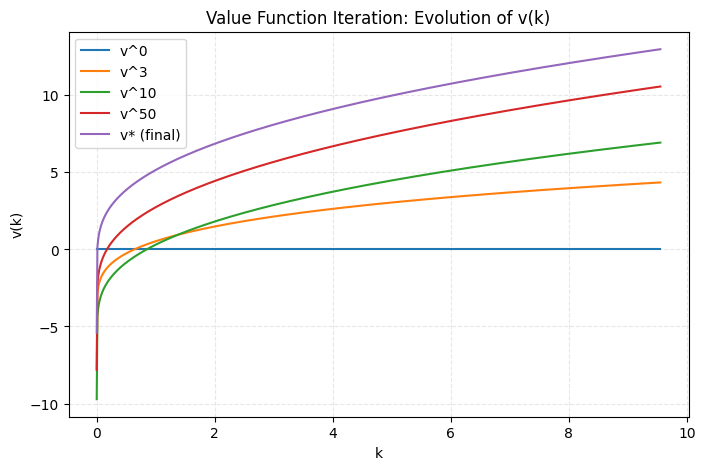

In [35]:

beta = 0.98
alpha = 0.3
A = 1.0
delta = 0.08

k_star = steady_state_k(beta, alpha, A, delta)
k_min = 1e-6
k_max = 2.0 * k_star
num_k = 800

k_grid_snap, v_final, kprime_snap, g_snap, snaps = vfi_stationary_with_snapshots(
    beta=beta, alpha=alpha, A=A, delta=delta,
    k_min=k_min, k_max=k_max, num_k=num_k,
    snapshot_iters=[0, 3, 10, 50]  
)

g = g_snap

plt.figure(figsize=(8,5))

for key, v_snap in snaps.items():
    label = f"v^{key}" if isinstance(key, int) else "v* (final)"
    plt.plot(k_grid_snap, v_snap, label=label)

plt.xlabel("k")
plt.ylabel("v(k)")
plt.title("Value Function Iteration: Evolution of v(k)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()




### Policy g(k), 45-degree line, and steady state k*


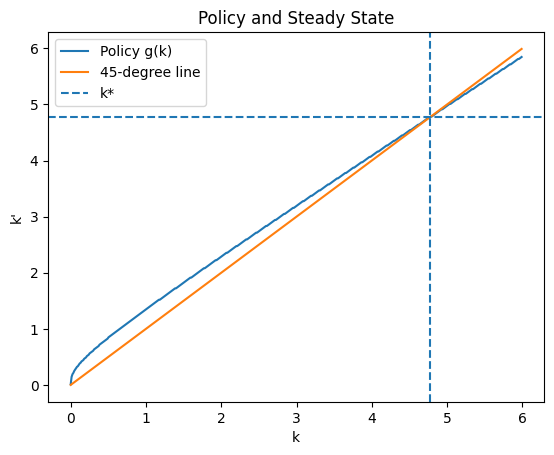

In [36]:

# Restrict domain to k in [0, 10]
k_grid = k_grid_snap
kprime_policy = kprime_snap
mask = (k_grid >= 0) & (k_grid <= 6)
k_plot = k_grid[mask]
kprime_plot = kprime_policy[mask]

plt.figure()
plt.plot(k_plot, kprime_plot, label="Policy g(k)")
plt.plot(k_plot, k_plot, label="45-degree line")
plt.axvline(k_star, linestyle="--", label="k*")
plt.axhline(k_star, linestyle="--")
plt.xlabel("k")
plt.ylabel("k'")
plt.title("Policy and Steady State")
plt.legend()
plt.show()



## 2) Steady state capital


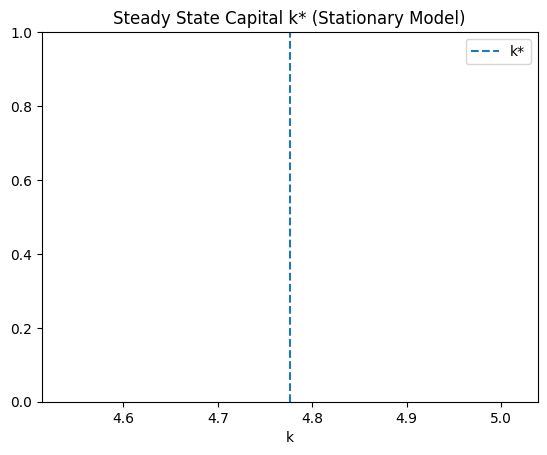

In [37]:

plt.figure()
plt.axvline(k_star, linestyle="--", label="k*")
plt.xlabel("k")
plt.title("Steady State Capital k* (Stationary Model)")
plt.legend()
plt.show()



## 3) Balanced Growth: Transformed VFI and Real Policy Mapping


/var/folders/pt/pzlm77zj5_9731nvb9k8hmyr0000gn/T/ipykernel_58125/2754383199.py:75: RuntimeWarning: invalid value encountered in log
  util = np.where(chat > 0.0, np.log(chat), -1e12)


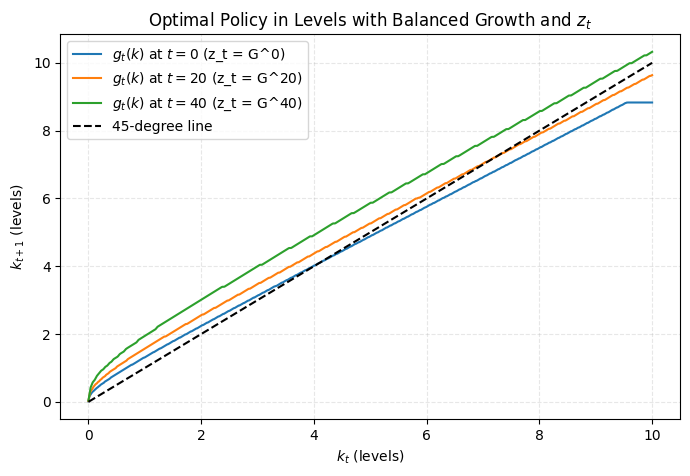

In [38]:
# --- Balanced-growth parameters ---
gamma = 0.02                                 # TFP growth when innovating
G = (1.0 + gamma)**(1.0 / (1.0 - alpha))     # z_{t+1}/z_t

# Solve transformed (balanced-growth) problem
khat_min = 1e-6
khat_max = 2.0 * k_star
num_khat = 800

khat_grid, vhat, khatprime_policy, ghat = vfi_transformed(
    beta=beta, alpha=alpha, delta=delta, G=G,
    k_min=khat_min, k_max=khat_max, num_k=num_khat
)

# --- Optimal policy in levels with BGP and z_t ---

# Grid for k_t in levels (you can adjust the max if you like)
k_min_plot = 0.0
k_max_plot = 10.0
k_grid_plot = np.linspace(k_min_plot, k_max_plot, 800)

# Choose some times along the BGP where z_t = G^t (z_0 = 1)
t_list = [0, 20, 40]   # you can change or add more

plt.figure(figsize=(8, 5))

for t in t_list:
    # On the balanced growth path with z_0 = 1:
    z_t = G**t
    
    # Real policy at time t: k_{t+1} = z_{t+1} * ghat(k_t / z_t)
    g_real_t = back_out_real_policy_from_transformed(ghat, G, z_t=z_t)
    
    kprime_t = g_real_t(k_grid_plot)
    plt.plot(k_grid_plot, kprime_t, label=fr"$g_t(k)$ at $t={t}$ (z_t = G^{t})")

# 45-degree line for reference
plt.plot(k_grid_plot, k_grid_plot, "k--", label="45-degree line")

plt.xlabel(r"$k_t$ (levels)")
plt.ylabel(r"$k_{t+1}$ (levels)")
plt.title("Optimal Policy in Levels with Balanced Growth and $z_t$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


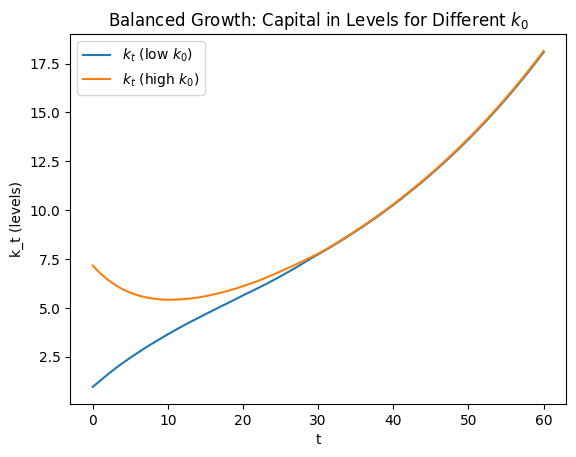

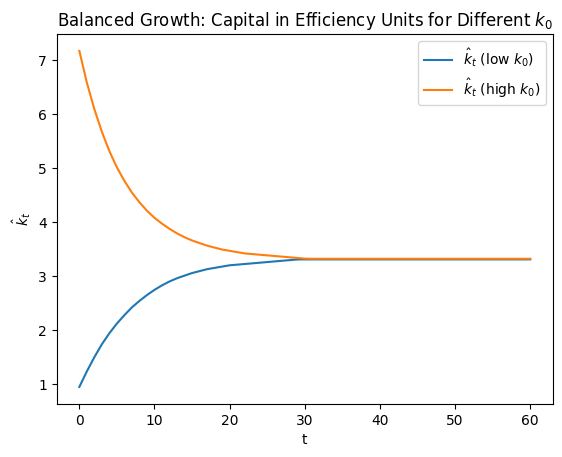

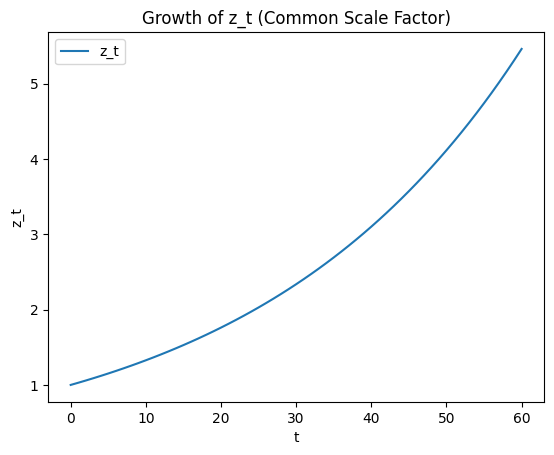

In [39]:
# --- Simulate two paths from different k0, with explicit z_t growth ---

T = 60
z0 = 1.0  # normalization at t = 0

# Two different initial capital stocks in levels
k0_low  = 0.2 * k_star      # below stationary k*
k0_high = 1.5 * k_star      # above stationary k*

# Simulate both paths
k_path_low,  z_path_low,  khat_path_low  = simulate_bg_from_ghat(ghat, k0_low,  z0=z0, G=G, T=T)
k_path_high, z_path_high, khat_path_high = simulate_bg_from_ghat(ghat, k0_high, z0=z0, G=G, T=T)

# 1) Plot k_t in levels for both initial conditions
plt.figure()
plt.plot(range(T+1), k_path_low,  label=r"$k_t$ (low $k_0$)")
plt.plot(range(T+1), k_path_high, label=r"$k_t$ (high $k_0$)")
plt.xlabel("t")
plt.ylabel("k_t (levels)")
plt.title("Balanced Growth: Capital in Levels for Different $k_0$")
plt.legend()
plt.show()

# 2) Plot hat{k}_t (efficiency units) for both initial conditions
plt.figure()
plt.plot(range(T+1), khat_path_low,  label=r"$\hat{k}_t$ (low $k_0$)")
plt.plot(range(T+1), khat_path_high, label=r"$\hat{k}_t$ (high $k_0$)")
plt.xlabel("t")
plt.ylabel(r"$\hat{k}_t$")
plt.title("Balanced Growth: Capital in Efficiency Units for Different $k_0$")
plt.legend()
plt.show()

# (Optional) 3) Plot z_t just to see the growth of the scaling factor
plt.figure()
plt.plot(range(T+1), z_path_low, label="z_t")
plt.xlabel("t")
plt.ylabel("z_t")
plt.title("Growth of z_t (Common Scale Factor)")
plt.legend()
plt.show()

# 4) Poverty Trap

## Threshold


Cutoff capital for innovation k_hat = 10.079


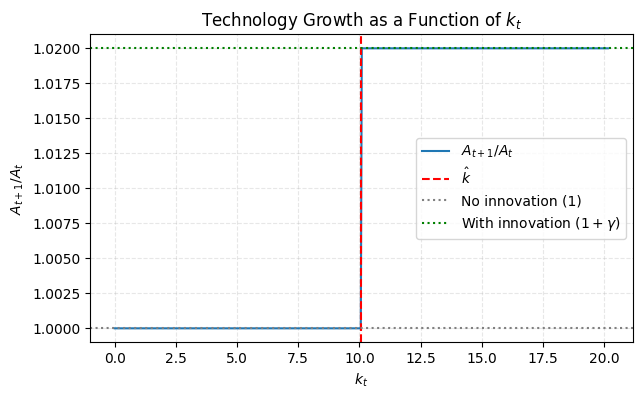

In [58]:
# --- Parameters for the innovation decision ---
gamma = 0.02   # long-run TFP growth rate when innovating
x = 0.04        # fixed R&D cost parameter (adjust if you like)

# Cutoff capital for innovation: k_hat = (z/gamma)^(1/alpha)
k_hat = (x / gamma)**(1.0 / alpha)
print(f"Cutoff capital for innovation k_hat = {k_hat:.3f}")

# k grid for the static innovation decision
k_innov = np.linspace(0.0, 2.0 * max(k_hat, k_star), 500)

# A_{t+1} / A_t as a function of k_t:
#   = 1 + gamma if k_t >= k_hat (innovate)
#   = 1 otherwise (no innovation)
A_ratio = np.where(k_innov >= k_hat, 1.0 + gamma, 1.0)

plt.figure(figsize=(7,4))
plt.plot(k_innov, A_ratio, label=r"$A_{t+1}/A_t$")
plt.axvline(k_hat, linestyle="--", color="red", label=r"$\hat k$")
plt.axhline(1.0, linestyle=":", color="gray", label="No innovation (1)")
plt.axhline(1.0 + gamma, linestyle=":", color="green", label=r"With innovation $(1+\gamma)$")
plt.xlabel(r"$k_t$")
plt.ylabel(r"$A_{t+1}/A_t$")
plt.title(r"Technology Growth as a Function of $k_t$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


# Multiple equilibria   
## $$\hat{k}>k_{ss}$$


k_ss = 4.776,  k_hat = 10.079
Balanced-growth factor G = 1.0287


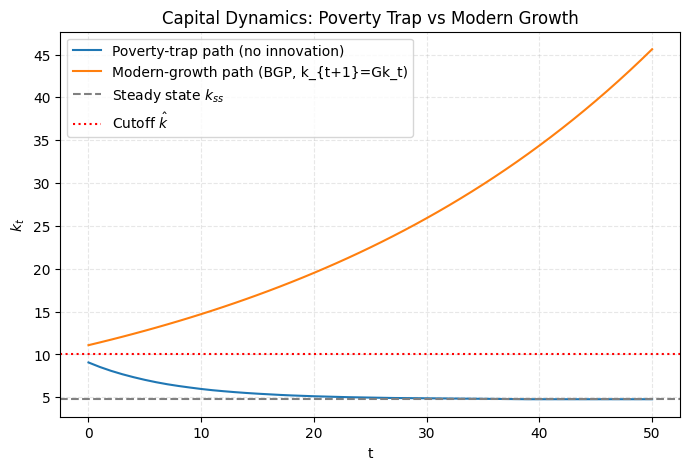

In [60]:
# --- Parameters already set earlier ---
# beta, alpha, A, delta
# gamma = 0.02
# x = 0.04
# k_star from steady_state_k(...)
# g from vfi_stationary_with_snapshots

# Cutoff capital for innovation
k_hat = (x / gamma)**(1.0 / alpha)
print(f"k_ss = {k_star:.3f},  k_hat = {k_hat:.3f}")

# Growth factor along BGP (your Solow 1 result)
G = (1.0 + gamma)**(1.0 / (1.0 - alpha))
print(f"Balanced-growth factor G = {G:.4f}")

# --- Simulators ---

def simulate_no_innovation(g_fun, k0, T=80):
    """Neoclassical stationary law of motion: k_{t+1} = g(k_t)."""
    k_path = np.empty(T+1)
    k_path[0] = k0
    for t in range(T):
        k_path[t+1] = g_fun(k_path[t])
    return k_path

def simulate_bgp_simple(k0, G, T=80):
    """Balanced growth path with k_{t+1} = G * k_t."""
    k_path = np.empty(T+1)
    k_path[0] = k0
    for t in range(T):
        k_path[t+1] = G * k_path[t]
    return k_path

# Horizon
T = 50

# Initial conditions relative to the cutoff
k0_poor = 0.9 * k_hat   # below cutoff -> no innovation -> poverty trap
k0_rich = 1.1 * k_hat   # above cutoff -> innovates -> BGP

# Paths
k_path_poor = simulate_no_innovation(g, k0_poor, T=T)
k_path_rich = simulate_bgp_simple(k0_rich, G, T=T)

# --- Plot: poverty trap vs modern growth ---

plt.figure(figsize=(8,5))
plt.plot(range(T+1), k_path_poor, label="Poverty-trap path (no innovation)")
plt.plot(range(T+1), k_path_rich, label="Modern-growth path (BGP, k_{t+1}=Gk_t)")

plt.axhline(k_star, linestyle="--", color="gray", label=r"Steady state $k_{ss}$")
plt.axhline(k_hat, linestyle=":", color="red", label=r"Cutoff $\hat k$")

plt.xlabel("t")
plt.ylabel(r"$k_t$")
plt.title("Capital Dynamics: Poverty Trap vs Modern Growth")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


# Unique equilibrium 
## $$\hat{k}<k_{ss}$$


Cutoff capital for innovation k_hat = 3.863


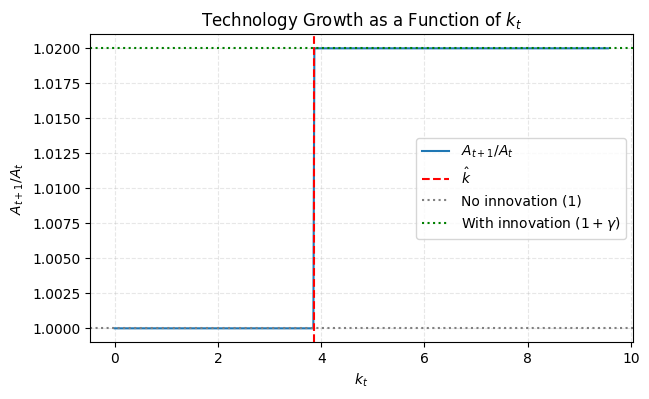

k_ss = 4.776,  k_hat = 3.863
Balanced-growth factor G = 1.0287
First time hitting or crossing k_hat: 10


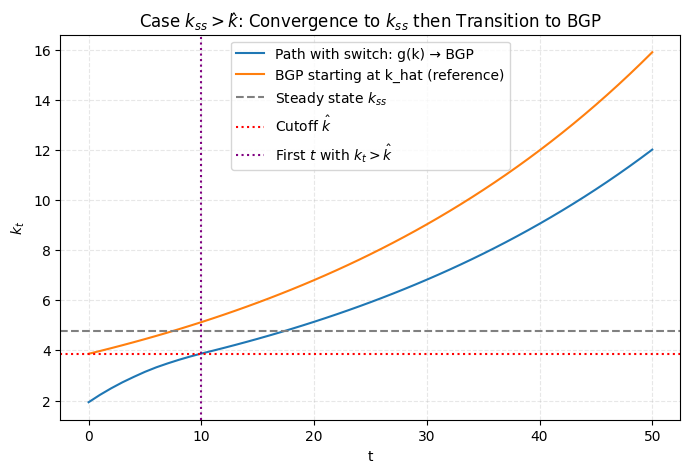

In [57]:
# --- Parameters for the innovation decision ---
gamma = 0.02   # long-run TFP growth rate when innovating
x = 0.03        # fixed R&D cost parameter (adjust if you like)

# Cutoff capital for innovation: k_hat = (z/gamma)^(1/alpha)
k_hat = (x / gamma)**(1.0 / alpha)
print(f"Cutoff capital for innovation k_hat = {k_hat:.3f}")

# k grid for the static innovation decision
k_innov = np.linspace(0.0, 2.0 * max(k_hat, k_star), 500)

# A_{t+1} / A_t as a function of k_t:
#   = 1 + gamma if k_t >= k_hat (innovate)
#   = 1 otherwise (no innovation)
A_ratio = np.where(k_innov >= k_hat, 1.0 + gamma, 1.0)

plt.figure(figsize=(7,4))
plt.plot(k_innov, A_ratio, label=r"$A_{t+1}/A_t$")
plt.axvline(k_hat, linestyle="--", color="red", label=r"$\hat k$")
plt.axhline(1.0, linestyle=":", color="gray", label="No innovation (1)")
plt.axhline(1.0 + gamma, linestyle=":", color="green", label=r"With innovation $(1+\gamma)$")
plt.xlabel(r"$k_t$")
plt.ylabel(r"$A_{t+1}/A_t$")
plt.title(r"Technology Growth as a Function of $k_t$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

# Cutoff capital for innovation
k_hat = (x / gamma)**(1.0 / alpha)
print(f"k_ss = {k_star:.3f},  k_hat = {k_hat:.3f}")

# Growth factor along BGP (your Solow 1 result)
G = (1.0 + gamma)**(1.0 / (1.0 - alpha))
print(f"Balanced-growth factor G = {G:.4f}")

# --- Simulators ---
def simulate_switch_to_bgp(g_fun, k0, k_hat, G, T=80):
    """
    Start with neoclassical policy k_{t+1} = g(k_t).
    As soon as k_t >= k_hat, switch permanently to BGP rule k_{t+1} = G k_t.
    Returns (k_path, t_switch):
      - k_path: array of length T+1
      - t_switch: first t such that k_t >= k_hat (or None if never reached)
    """
    k_path = np.empty(T+1)
    k_path[0] = k0
    switched = False
    t_switch = None

    for t in range(T):
        if (not switched) and (k_path[t] >= k_hat):
            switched = True
            t_switch = t

        if not switched:
            # No innovation yet: stationary neoclassical dynamics
            k_path[t+1] = g_fun(k_path[t])
        else:
            # Once k_t >= k_hat, we innovate forever: BGP k_{t+1} = G k_t
            k_path[t+1] = G * k_path[t]

    return k_path, t_switch

T = 50

# Start below the threshold
k0_low = 0.5 * k_hat   # clearly below cutoff

# Path that initially follows g, then switches to BGP when k_t >= k_hat
k_path_switch, t_switch = simulate_switch_to_bgp(g, k0_low, k_hat, G, T=T)

print("First time hitting or crossing k_hat:", t_switch)

# For comparison: a pure BGP path that starts exactly at k_hat
k_path_bgp_from_hat = simulate_bgp_simple(k_hat, G, T=T)

plt.figure(figsize=(8,5))

plt.plot(range(T+1), k_path_switch, label="Path with switch: g(k) → BGP")

plt.plot(range(T+1), k_path_bgp_from_hat, label="BGP starting at k_hat (reference)")

# Lines for k_ss and k_hat
plt.axhline(k_star, linestyle="--", color="gray", label=r"Steady state $k_{ss}$")
plt.axhline(k_hat, linestyle=":", color="red", label=r"Cutoff $\hat k$")

# Mark the period we first hit the threshold
if t_switch is not None:
    plt.axvline(t_switch, linestyle=":", color="purple",
                label=r"First $t$ with $k_t > \hat k$")

plt.xlabel("t")
plt.ylabel(r"$k_t$")
plt.title("Case $k_{ss} > k̂$: Convergence to $k_{ss}$ then Transition to BGP")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()
